In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

In [ ]:
# Ячейка № 2

# задание функции, возвращающей
# координаты ансамбля траекторий
# броуновской частицы,
# начальные точки которых одинаковы


def Walk2(N_step, N_trial, p, x0, dx):
    # N_step - число шагов, совершенных
    #          броуновской частицей
    # N_trial - число независимых испытаний
    #           метода Монте-Карло
    # p - пороговое значение вероятности
    # x0 - координата начальной точки
    # dx - переменная, знак которой определяет
    #      направление движения пешехода

    # инициализация массива Z
    # с размерностью N_step+1 x N_trial,
    # используемого для хранения
    # ансамбля независимых траекторий
    # броуновской частицы
    Z = np.zeros([N_step + 1, N_trial])

    # задание начальной координаты
    # каждой траектории
    # броуновской частицы
    Z[0, :] = x0

    # реализация метода Монте-Карло
    # i - счетчик шагов метода Монте-Карло
    # j - счетчик шагов броуновской частицы
    # на i-ом шаге метода Монте-Карло
    for i in range(1, N_trial):
        x = x0
        d = dx
        K = 1
        for j in range(1, N_step + 1):
            x = x + d
            Z[j, i] = x
            K = K + 1
            if p < random.uniform(0, 1):
                d = -d
    return Z

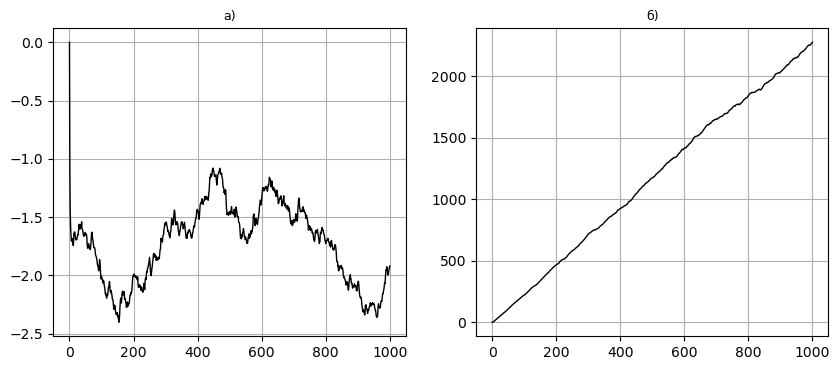

In [3]:
# Ячейка № 3

# вычисление ансамбля
# независимых траекторий
# броуновской частицы,
# стартующих из выбранной
# начальной точки, и
# визуализация средних
# по ансамблю реализаций
# траектории и квадрата
# смещения броуновской частицы

# инициализация генератора случайных чисел
random.seed()

# задание числа
# шагов броуновской частицы
N_step = 10**3

# задание числа шагов
# метода Монте-Карло
N_trial = 2 * 10**3

# задание порогового
# значения вероятности
p = 0.7

# задание координаты начальной
#  точки каждой траектории
# броуновской частицы
x0 = 0

# задание направления
# смещения броуновской частицы
# на первом шаге случайных блужданий
dx = -1

# вычисление координат
# ансамбля независящих
# друг от друга траекторий
# стартующих из одной точки
M = Walk2(N_step, N_trial, p, x0, dx)

# инициализация массива,
# для хранения координат
# средней по ансамблю
# траектории броуновской частицы
X = np.zeros(N_step + 1)

# инициализация массива,
# для хранения значений
# среднего по ансамблю
# квадрата смещения
# броуновской частицы
X2 = np.zeros(N_step + 1)

# вычисление мгновенных значений
# зависимостей координат и
# cреднеквадратического отклонения
# от номера шага метода Монте-Карло,
# усредненных по ансамблю траекторий
for j in range(N_step + 1):
    X[j] = np.mean(M[j, :])
    X2[j] = np.mean((M[j, :] - X[j]) ** 2)


# визуализация мгновенных значений
# зависимостей координат и
# cреднеквадратического отклонения
# от номера шага метода Монте-Карло,
# усредненных по ансамблю траекторий

fig = plt.figure(figsize=(10, 4))

ax = plt.subplot(1, 2, 1)
ax.plot(X[:], "-k", lw=1)
ax.grid(True)
ax.set_title("а)", fontsize=9)

ax = plt.subplot(1, 2, 2)
ax.plot(X2[:], "-k", lw=1)
ax.grid(True)
ax.set_title("б)", fontsize=9)

plt.show()